# 03 — Spatial patterns

**Purpose:** Visualize HH and LL clusters, examine distribution of HH frequency across seeds, and run connected-component analysis for hotspot stability. Observation-level cross-seed stability requires a fixed test set across runs.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    load_split,
    run_spatial,
    select_rashomon_global,
    mean_variance,
    pointwise_variance,
)
from analysis.spatial import extract_hh_components
from analysis.stability import hh_selection_frequency, hh_jaccard_matrix, summarize_hh_stability

RESULTS_DEFAULT_DIR = ROOT / "results"
RESULTS_FIXED_TEST_DIR = ROOT / "results_fixed_test"
FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

## All datasets: compute HH masks across seeds

For each dataset and run we compute spatial analysis (Moran's I, LISA) and collect HH_mask, LL_mask, and pointwise variance.

In [2]:
DATASET = "compas"
K = 25
k_nn = 30
USE_FIXED_TEST = True  # Required for valid observation-level cross-seed stability.

RESULTS_DIR = RESULTS_FIXED_TEST_DIR if USE_FIXED_TEST else RESULTS_DEFAULT_DIR
dataset_dir = RESULTS_DIR / DATASET
run_dirs = _get_run_dirs(dataset_dir)
if not run_dirs:
    raise SystemExit(f"No runs found in {dataset_dir}. "
                     f"Run fixed-test training first: run_training_pipeline_fixed_test.py")

spatial_by_run = []
test_idx_ref = None
test_indices_aligned = True

for run_dir in run_dirs:
    split = load_split(run_dir)
    test_idx = np.asarray(split["test"], dtype=int)

    if test_idx_ref is None:
        test_idx_ref = test_idx
    elif not np.array_equal(test_idx_ref, test_idx):
        test_indices_aligned = False

    n_cand = len(load_meta(run_dir))
    K_actual = min(K, n_cand)
    X_test = get_transformed_test_features(run_dir, DATASET)
    res = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
    res["run_dir"] = run_dir.name
    res["test_idx"] = test_idx

    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K_actual)
    res["mean_variance"] = mean_variance(P_test[idx], ddof=0)
    spatial_by_run.append(res)

print(f"Computed spatial metrics for {len(spatial_by_run)} runs.")
print(f"Test indices aligned across runs: {test_indices_aligned}")

if not test_indices_aligned:
    raise ValueError(
        "Observation-level HH stability is invalid because test sets differ across runs. "
        "Use fixed-test artifacts (results_fixed_test/...)."
    )

Computed spatial metrics for 10 runs.
Test indices aligned across runs: True


## HH stability analysis and visualizations

Compute HH selection frequency across seeds, Jaccard overlap matrix, stability summary, and save figures (frequency scatter, Jaccard heatmap, HH location in feature space) plus component summary table.

In [3]:
# Part 1: HH stability
hh_masks = [r["HH_mask"] for r in spatial_by_run]
freq = hh_selection_frequency(hh_masks)
J = hh_jaccard_matrix(hh_masks)
stability_summary = summarize_hh_stability(hh_masks)

# X_test from first run for plotting (same test size across runs)
run_dir0 = run_dirs[0]
X_test = get_transformed_test_features(run_dir0, DATASET)
if hasattr(X_test, "values"):
    X_plot = np.asarray(X_test.values, dtype=float)
else:
    X_plot = np.asarray(X_test, dtype=float)
n_features = X_plot.shape[1]

if n_features == 2:
    coords = X_plot
elif n_features == 1:
    coords = np.column_stack([X_plot.ravel(), np.zeros(X_plot.shape[0])])
else:
    pca = PCA(n_components=2).fit(X_plot)
    coords = pca.transform(X_plot)

# Part 2A: HH frequency visualization
plt.figure()
sc = plt.scatter(coords[:, 0], coords[:, 1], c=freq, cmap="viridis", s=20, alpha=0.8)
plt.colorbar(sc, label="HH selection frequency across seeds")
plt.xlabel("PC1" if n_features > 2 else "Feature 1")
plt.ylabel("PC2" if n_features > 2 else "Feature 2")
plt.title(f"HH selection frequency — {DATASET}")
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_stability_freq_{DATASET}.pdf")
plt.close()

# Part 2B: Jaccard heatmap
run_labels = [r["run_dir"] for r in spatial_by_run]
plt.figure(figsize=(6, 5))
sns.heatmap(J, xticklabels=run_labels, yticklabels=run_labels, annot=False, cmap="viridis")
plt.title("HH Jaccard Overlap Across Seeds")
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_jaccard_heatmap_{DATASET}.pdf")
plt.close()

# Part 3: Component summary + stability metrics
component_stats = []
for r in spatial_by_run:
    lisa_df = pd.DataFrame({"cluster": np.where(r["HH_mask"], "HH", "NS")})
    W = r["W"].to_sparse() if hasattr(r["W"], "to_sparse") else r["W"].sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    n_comp = len(components)
    max_size = max(len(inds) for inds in components.values()) if components else 0
    component_stats.append({"run": r["run_dir"], "n_components": n_comp, "max_component_size": max_size})

hh_component_summary = pd.DataFrame(component_stats)
for k, v in stability_summary.items():
    hh_component_summary[k] = v
hh_component_summary.to_csv(TABLE_DIR / f"hh_component_summary_{DATASET}.csv", index=False)
display(hh_component_summary)

# Part 4: HH location in feature space (representative run: seed=0)
r0 = spatial_by_run[0]
HH_mask0 = r0["HH_mask"]
plt.figure()
plt.scatter(coords[~HH_mask0, 0], coords[~HH_mask0, 1], c="lightgray", s=20, alpha=0.7, label="all")
plt.scatter(coords[HH_mask0, 0], coords[HH_mask0, 1], c="red", s=30, alpha=0.9, label="HH")
plt.xlabel("PC1" if n_features > 2 else "Feature 1")
plt.ylabel("PC2" if n_features > 2 else "Feature 2")
plt.title("HH hotspots in feature space")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_location_{DATASET}.pdf")
plt.close()

,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard
0,seed=0,3,81,0.056133,0.339483,0.052174,0.617647
1,seed=1,4,28,0.056133,0.339483,0.052174,0.617647
2,seed=2,3,32,0.056133,0.339483,0.052174,0.617647
3,seed=3,1,33,0.056133,0.339483,0.052174,0.617647
4,seed=4,5,41,0.056133,0.339483,0.052174,0.617647
5,seed=5,1,36,0.056133,0.339483,0.052174,0.617647
6,seed=6,4,70,0.056133,0.339483,0.052174,0.617647
7,seed=7,6,31,0.056133,0.339483,0.052174,0.617647
8,seed=8,5,60,0.056133,0.339483,0.052174,0.617647
9,seed=9,3,26,0.056133,0.339483,0.052174,0.617647


## Stability: HH count and variance summary per run

Plot number of HH points and mean pointwise variance per run to assess stability across seeds.

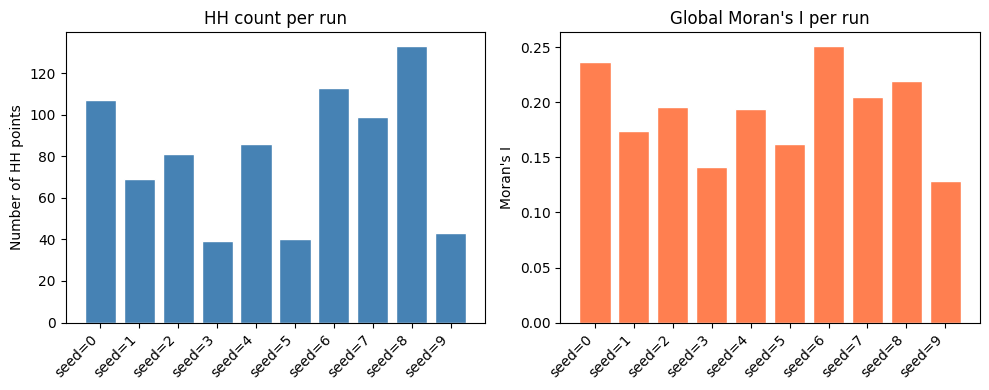

In [4]:
n_hh_per_run = [int(np.sum(r["HH_mask"])) for r in spatial_by_run]
run_labels = [r["run_dir"] for r in spatial_by_run]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(range(len(n_hh_per_run)), n_hh_per_run, color="steelblue", edgecolor="white")
ax1.set_xticks(range(len(run_labels)))
ax1.set_xticklabels(run_labels, rotation=45, ha="right")
ax1.set_ylabel("Number of HH points")
ax1.set_title("HH count per run")

moran_per_run = [r["moran_i"] for r in spatial_by_run]
ax2.bar(range(len(moran_per_run)), moran_per_run, color="coral", edgecolor="white")
ax2.set_xticks(range(len(run_labels)))
ax2.set_xticklabels(run_labels, rotation=45, ha="right")
ax2.set_ylabel("Moran's I")
ax2.set_title("Global Moran's I per run")
plt.tight_layout()
fig.savefig(FIG_DIR / f"hh_moran_per_run_{DATASET}.pdf", bbox_inches="tight")
plt.show()

## Correlation: mean variance vs Moran's I per run

Plot mean variance (multiplicity) against global Moran's I (spatial clustering of variance) across runs.

- **Positive correlation:** More multiplicity → stronger spatial clustering of disagreement. Multiplicity concentrates in regions rather than being diffuse.
- **No (or weak) correlation:** Spatial structure of hotspots can exist even when overall multiplicity is small; the two are not simply coupled.

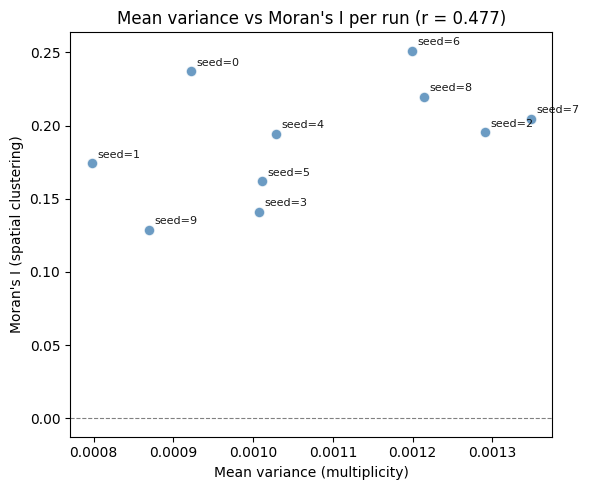

→ Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.


In [5]:
corr_df = pd.DataFrame({
    "run": [r["run_dir"] for r in spatial_by_run],
    "mean_variance": [r["mean_variance"] for r in spatial_by_run],
    "moran_i": [r["moran_i"] for r in spatial_by_run],
})
r_pearson = np.corrcoef(corr_df["mean_variance"], corr_df["moran_i"])[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(corr_df["mean_variance"], corr_df["moran_i"], s=60, alpha=0.8, color="steelblue", edgecolor="white")
for _, row in corr_df.iterrows():
    ax.annotate(row["run"], (row["mean_variance"], row["moran_i"]), fontsize=8, alpha=0.9, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean variance (multiplicity)")
ax.set_ylabel("Moran's I (spatial clustering)")
ax.set_title(f"Mean variance vs Moran's I per run (r = {r_pearson:.3f})")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / f"variance_vs_moran_{DATASET}.pdf", bbox_inches="tight")
plt.show()

if r_pearson > 0.2:
    print("→ Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.")
elif r_pearson < -0.2:
    print("→ Negative correlation: higher multiplicity tends to go with weaker spatial clustering.")
else:
    print("→ Weak or no correlation: spatial structure of hotspots can exist even when overall multiplicity is small.")

## Connected component analysis (hotspot regions)

For one run, extract HH connected components using the kNN graph and report region sizes. Uses `analysis.spatial.extract_hh_components`. The same W (from spatial_analysis) is used; kNN is directed. For undirected region connectivity you could symmetrize W before extraction.

In [6]:
# Use first run for component analysis
r0 = spatial_by_run[0]
HH_mask = r0["HH_mask"]
W_pysal = r0["W"]
W_sparse = W_pysal.to_sparse() if hasattr(W_pysal, "to_sparse") else W_pysal.sparse

lisa_df = pd.DataFrame({
    "cluster": np.where(HH_mask, "HH", "NS"),
})
comp_id, components = extract_hh_components(lisa_df, W_sparse, min_size=5)

print(f"Run: {r0['run_dir']}")
print(f"HH points: {HH_mask.sum()}")
print(f"Connected components (min_size=5): {len(components)}")
for cid, inds in components.items():
    print(f"  Component {cid}: n = {len(inds)}")

Run: seed=0
HH points: 107
Connected components (min_size=5): 3
  Component 0: n = 81
  Component 1: n = 10
  Component 2: n = 14


## Region persistence summary

Across runs, summarize number of HH components and largest component size (when available) to assess hotspot stability.

In [7]:
# Component summary (with stability metrics) was computed and saved in the HH stability cell above.
# Saved to: tables/hh_component_summary_{DATASET}.csv
print("HH component summary (min_size=5) with stability metrics:")
display(hh_component_summary)
print(f"Mean n_components: {hh_component_summary['n_components'].mean():.2f}")
print(f"Mean max_component_size: {hh_component_summary['max_component_size'].mean():.2f}")

HH component summary (min_size=5) with stability metrics:


,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard
0,seed=0,3,81,0.056133,0.339483,0.052174,0.617647
1,seed=1,4,28,0.056133,0.339483,0.052174,0.617647
2,seed=2,3,32,0.056133,0.339483,0.052174,0.617647
3,seed=3,1,33,0.056133,0.339483,0.052174,0.617647
4,seed=4,5,41,0.056133,0.339483,0.052174,0.617647
5,seed=5,1,36,0.056133,0.339483,0.052174,0.617647
6,seed=6,4,70,0.056133,0.339483,0.052174,0.617647
7,seed=7,6,31,0.056133,0.339483,0.052174,0.617647
8,seed=8,5,60,0.056133,0.339483,0.052174,0.617647
9,seed=9,3,26,0.056133,0.339483,0.052174,0.617647


Mean n_components: 3.50
Mean max_component_size: 43.80


## HH hotspot reproducibility across runs

Goal: Test whether HH hotspots are reproducible across random splits/seeds (not Monte-Carlo noise).

- **Stable point ID:** Original dataset row index from the split (test indices) so the same row is comparable across runs.
- **(1) Point-level:** Per-point HH frequency across runs; histogram and fraction of points with freq ≥ 0.8, ≥ 0.5.
- **(2) Region-level:** HH connected components per run (same kNN graph); compare regions via Jaccard overlap and region persistence (how often a similar component reappears).
- **(3) Summary:** Mean ± std over runs: n_HH, n_components, max component size, total HH mass (sum of variance over HH points).

In [8]:
# Build per-run data with stable point IDs (original dataset row index from split)
from collections import defaultdict

n_cand = len(load_meta(run_dirs[0]))
K_actual = min(K, n_cand)

run_data = []
for r in spatial_by_run:
    run_dir = dataset_dir / r["run_dir"]
    split = load_split(run_dir)
    test_idx = split["test"]  # stable IDs: original row indices in the dataset
    HH_mask = r["HH_mask"]
    # Pointwise variance for this run (for total HH mass)
    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K_actual)
    v = pointwise_variance(P_test[idx], ddof=0)
    # Components: map to stable IDs
    lisa_df = pd.DataFrame({"cluster": np.where(HH_mask, "HH", "NS")})
    W = r["W"].to_sparse() if hasattr(r["W"], "to_sparse") else r["W"].sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    comp_stable = {
        cid: set(int(test_idx[i]) for i in inds)
        for cid, inds in components.items()
    }
    run_data.append({
        "run_dir": r["run_dir"],
        "test_idx": test_idx,
        "HH_mask": HH_mask,
        "v": v,
        "n_HH": int(np.sum(HH_mask)),
        "components": components,
        "comp_stable": comp_stable,
        "n_components": len(components),
        "max_component_size": max(len(inds) for inds in components.values()) if components else 0,
        "total_HH_mass": float(np.sum(v[HH_mask])),
    })

### (1) Point-level stability: How often is point x in HH?

Per-point HH frequency = (number of runs where point was in test and was HH) / (number of runs where point was in test). Histogram and fraction of points with freq ≥ 0.8, ≥ 0.5.

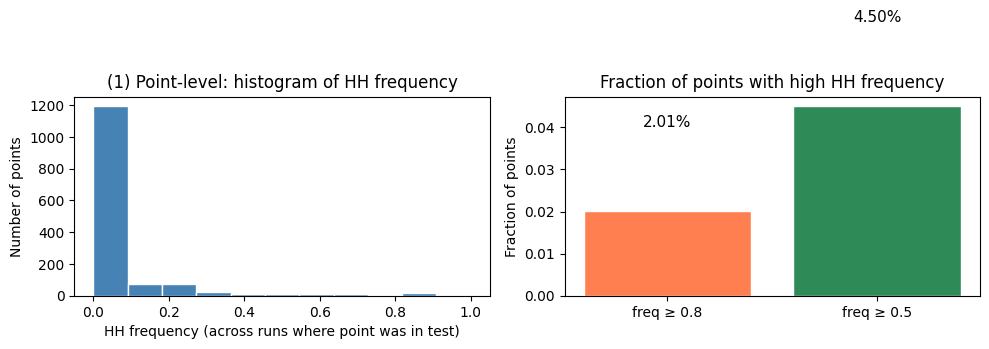

Fraction of points with HH freq ≥ 0.8: 2.01%
Fraction of points with HH freq ≥ 0.5: 4.50%


In [9]:
# (1) Point-level HH frequency (stable_id = original dataset row index)
stable_id_to_hh = defaultdict(list)  # stable_id -> list of 0/1 (HH in that run)
for rd in run_data:
    for i, sid in enumerate(rd["test_idx"]):
        stable_id_to_hh[int(sid)].append(1 if rd["HH_mask"][i] else 0)

hh_freq = {}
for sid, hh_list in stable_id_to_hh.items():
    hh_freq[sid] = np.mean(hh_list)

freq_values = np.array(list(hh_freq.values()))
n_runs = len(run_dirs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(freq_values, bins=np.linspace(0, 1, 12), color="steelblue", edgecolor="white")
ax1.set_xlabel("HH frequency (across runs where point was in test)")
ax1.set_ylabel("Number of points")
ax1.set_title("(1) Point-level: histogram of HH frequency")

frac_80 = np.mean(freq_values >= 0.8)
frac_50 = np.mean(freq_values >= 0.5)
ax2.bar(["freq ≥ 0.8", "freq ≥ 0.5"], [frac_80, frac_50], color=["coral", "seagreen"], edgecolor="white")
ax2.set_ylabel("Fraction of points")
ax2.set_title("Fraction of points with high HH frequency")
for i, (lbl, val) in enumerate([("≥0.8", frac_80), ("≥0.5", frac_50)]):
    ax2.text(i, val + 0.02, f"{val:.2%}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Fraction of points with HH freq ≥ 0.8: {frac_80:.2%}")
print(f"Fraction of points with HH freq ≥ 0.5: {frac_50:.2%}")

### (2) Region-level stability: Jaccard overlap and region persistence

For each run, HH components are sets of stable IDs. Compare across runs: Jaccard(A,B) = |A∩B|/|A∪B|. For each component in a run, find best-matching component in another run (max Jaccard). **Region persistence:** fraction of other runs that have at least one component with Jaccard > 0.3 to this one.

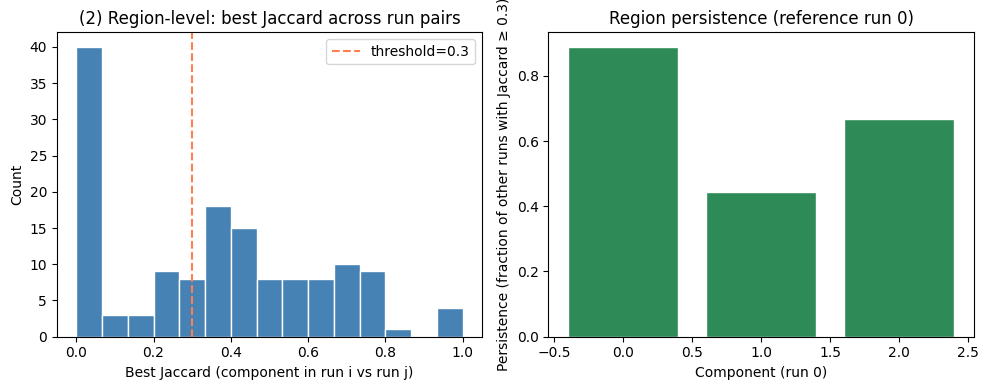

Mean best Jaccard across run pairs: 0.349 ± 0.280
Mean region persistence (run 0): 66.67%


In [10]:
# (2) Region-level: Jaccard between component node sets, region persistence
def jaccard(A, B):
    if len(A) == 0 and len(B) == 0:
        return 1.0
    inter = len(A & B)
    union = len(A | B)
    return inter / union if union else 0.0

JACCARD_THRESHOLD = 0.3
run_pairs = [(i, j) for i in range(len(run_data)) for j in range(len(run_data)) if i < j]
best_jaccards = []  # one per (run_i, run_j, comp in i): best Jaccard to any comp in j
for i, j in run_pairs:
    for cid, A in run_data[i]["comp_stable"].items():
        best = max(
            (jaccard(A, B) for B in run_data[j]["comp_stable"].values()),
            default=0.0,
        )
        best_jaccards.append(best)

# Region persistence: for each component in run 0, in how many other runs does a comp match (Jaccard > thresh)?
ref_run = 0
persistence = []
for cid, A in run_data[ref_run]["comp_stable"].items():
    count = 0
    for other in range(len(run_data)):
        if other == ref_run:
            continue
        best = max(
            (jaccard(A, B) for B in run_data[other]["comp_stable"].values()),
            default=0.0,
        )
        if best >= JACCARD_THRESHOLD:
            count += 1
    persistence.append(count / (len(run_data) - 1) if len(run_data) > 1 else 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(best_jaccards, bins=np.linspace(0, 1, 16), color="steelblue", edgecolor="white")
ax1.axvline(JACCARD_THRESHOLD, color="coral", linestyle="--", label=f"threshold={JACCARD_THRESHOLD}")
ax1.set_xlabel("Best Jaccard (component in run i vs run j)")
ax1.set_ylabel("Count")
ax1.set_title("(2) Region-level: best Jaccard across run pairs")
ax1.legend()

ax2.bar(range(len(persistence)), persistence, color="seagreen", edgecolor="white")
ax2.set_ylabel("Persistence (fraction of other runs with Jaccard ≥ 0.3)")
ax2.set_xlabel("Component (run 0)")
ax2.set_title("Region persistence (reference run 0)")
plt.tight_layout()
plt.show()
print(f"Mean best Jaccard across run pairs: {np.mean(best_jaccards):.3f} ± {np.std(best_jaccards):.3f}")
print(f"Mean region persistence (run 0): {np.mean(persistence):.2%}" if persistence else "No components in run 0.")

### (3) Summary stability statistics (mean ± std over runs)

Per run: number of HH points, number of HH components, size of largest HH component, total HH mass (sum of pointwise variance over HH points).

In [11]:
# (3) Summary stability statistics
summary_df = pd.DataFrame([
    {
        "run": rd["run_dir"],
        "n_HH": rd["n_HH"],
        "n_components": rd["n_components"],
        "max_component_size": rd["max_component_size"],
        "total_HH_mass": rd["total_HH_mass"],
    }
    for rd in run_data
])
stats = {
    "n_HH": (summary_df["n_HH"].mean(), summary_df["n_HH"].std()),
    "n_components": (summary_df["n_components"].mean(), summary_df["n_components"].std()),
    "max_component_size": (summary_df["max_component_size"].mean(), summary_df["max_component_size"].std()),
    "total_HH_mass": (summary_df["total_HH_mass"].mean(), summary_df["total_HH_mass"].std()),
}
report = pd.DataFrame([
    {"metric": k, "mean": v[0], "std": v[1], "mean ± std": f"{v[0]:.2f} ± {v[1]:.2f}"}
    for k, v in stats.items()
])
print("(3) Summary stability (mean ± std over runs):")
display(report)
display(summary_df)

(3) Summary stability (mean ± std over runs):


,metric,mean,std,mean ± std
0,n_HH,81.00000,32.974738,81.00 ± 32.97
1,n_components,3.50000,1.649916,3.50 ± 1.65
2,max_component_size,43.80000,19.401031,43.80 ± 19.40
3,total_HH_mass,0.34263,0.135689,0.34 ± 0.14


,run,n_HH,n_components,max_component_size,total_HH_mass
0,seed=0,107,3,81,0.309301
1,seed=1,69,4,28,0.229724
2,seed=2,81,3,32,0.520607
3,seed=3,39,1,33,0.180253
4,seed=4,86,5,41,0.288552
5,seed=5,40,1,36,0.259140
6,seed=6,113,4,70,0.437025
7,seed=7,99,6,31,0.526163
8,seed=8,133,5,60,0.481412
9,seed=9,43,3,26,0.194128


## Family-wise Moran/LISA comparison

Compute Moran's I and HH counts for per-family Rashomon sets (top-K=25 per family) and compare to global. This helps determine whether multiplicity hotspots originate from inter-family or intra-family diversity.

Global mean HH = 81.0, Global mean Moran's I = 0.1908



,family,moran_mean,moran_std,n_hh_mean,n_hh_std,mean_var_mean,mean_var_std
0,GBM,0.241534,0.057654,85.6,22.984052,0.001111,0.000255
1,LogReg,0.118564,0.121270,38.3,49.535733,0.000057,0.000138
2,MLP,0.430351,0.059692,245.7,35.302030,0.001326,0.000110
3,RF,0.158262,0.044086,99.5,29.930475,0.003209,0.000236
4,kNN,0.090822,0.017132,76.9,35.619751,0.010571,0.001428


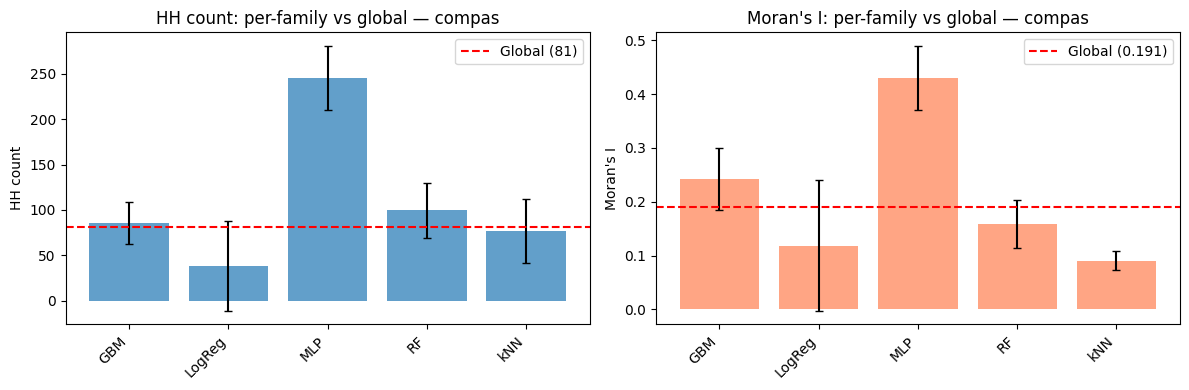

In [12]:
from analysis.run_analysis import run_spatial_per_family, select_rashomon_global, pointwise_variance, spatial_analysis

fam_records = []
glob_records = []

for run_dir in run_dirs:
    seed_name = run_dir.name
    X_test = get_transformed_test_features(run_dir, DATASET)

    # Per-family spatial
    fam_results = run_spatial_per_family(run_dir, X_test, K=K, k=k_nn, seed=42)
    for family, res in fam_results.items():
        fam_records.append({
            "run": seed_name, "family": family,
            "moran_i": res["moran_i"], "n_hh": res["n_hh"],
            "mean_variance": res["mean_variance"],
        })

    # Global spatial for comparison
    idx_g = select_rashomon_global(run_dir, K=K)
    P_test = load_P_test(run_dir)
    v_g = pointwise_variance(P_test[idx_g])
    sp_g = spatial_analysis(v_g, X_test, k=k_nn, seed=42)
    glob_records.append({
        "run": seed_name,
        "moran_i": sp_g["moran_i"], "n_hh": int(sp_g["HH_mask"].sum()),
        "mean_variance": float(v_g.mean()),
    })

fam_df = pd.DataFrame(fam_records)
glob_df = pd.DataFrame(glob_records)

# Aggregate
fam_agg = fam_df.groupby("family").agg(
    moran_mean=("moran_i", "mean"), moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"), n_hh_std=("n_hh", "std"),
    mean_var_mean=("mean_variance", "mean"), mean_var_std=("mean_variance", "std"),
).reset_index()

glob_mean_hh = glob_df["n_hh"].mean()
glob_mean_moran = glob_df["moran_i"].mean()

print(f"Global mean HH = {glob_mean_hh:.1f}, Global mean Moran's I = {glob_mean_moran:.4f}")
print()
display(fam_agg)

# Bar plot: HH count per family vs global
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
families = fam_agg["family"].values
x = range(len(families))

ax1.bar(x, fam_agg["n_hh_mean"], yerr=fam_agg["n_hh_std"], capsize=3, alpha=0.7)
ax1.axhline(glob_mean_hh, color="red", ls="--", label=f"Global ({glob_mean_hh:.0f})")
ax1.set_xticks(list(x)); ax1.set_xticklabels(families, rotation=45, ha="right")
ax1.set_ylabel("HH count"); ax1.set_title(f"HH count: per-family vs global — {DATASET}")
ax1.legend()

ax2.bar(x, fam_agg["moran_mean"], yerr=fam_agg["moran_std"], capsize=3, alpha=0.7, color="coral")
ax2.axhline(glob_mean_moran, color="red", ls="--", label=f"Global ({glob_mean_moran:.3f})")
ax2.set_xticks(list(x)); ax2.set_xticklabels(families, rotation=45, ha="right")
ax2.set_ylabel("Moran's I"); ax2.set_title(f"Moran's I: per-family vs global — {DATASET}")
ax2.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / f"family_vs_global_spatial_{DATASET}.pdf", bbox_inches="tight")
plt.show()